<a href="https://colab.research.google.com/github/walmirpacheco/Sistema_Reconhecimento_Facial/blob/main/Sistema_Reconhecimento_Facial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mtcnn opencv-python-headless scikit-learn

# Verificar instalação
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.3 MB/s eta 0:00:00
TensorFlow version: 2.19.0


In [2]:
# Importações principais
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from mtcnn import MTCNN
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import os
from google.colab import files
from IPython.display import display, clear_output
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas as bibliotecas importadas com sucesso!")

✅ Todas as bibliotecas importadas com sucesso!


In [19]:
class SistemaReconhecimentoFacial:
    def __init__(self):
        """Inicializa o sistema de reconhecimento facial"""
        self.detector = MTCNN()
        self.modelo_face = None
        self.classificador = None
        self.encoder = LabelEncoder()
        self.nomes_pessoas = []
        self.embeddings = []
        print("✅ Sistema de Reconhecimento Facial inicializado!")

    def detectar_face(self, imagem_path):
        """
        Detecta faces em uma imagem usando MTCNN
        """
        try:
            # Carregar imagem
            img = cv2.imread(imagem_path)
            if img is None:
                print(f"❌ Erro: Não foi possível carregar a imagem {imagem_path}")
                return None, None

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Detectar faces
            faces = self.detector.detect_faces(img_rgb)

            # Desenhar retângulos nas faces detectadas
            img_resultado = img_rgb.copy()
            for face in faces:
                x, y, w, h = face['box']
                # Ajustar coordenadas negativas
                x, y = max(0, x), max(0, y)
                cv2.rectangle(img_resultado, (x, y), (x+w, y+h), (0, 255, 0), 2)

                # Adicionar pontos faciais
                for key, value in face['keypoints'].items():
                    cv2.circle(img_resultado, value, 2, (255, 0, 0), -1)

            print(f"✅ {len(faces)} face(s) detectada(s) na imagem")
            return img_resultado, faces

        except Exception as e:
            print(f"❌ Erro na detecção de face: {e}")
            return None, None


    def criar_modelo_embeddings(self):
        """
        Cria um modelo para extrair embeddings faciais usando ResNet50
        """
        try:
            # Carregar ResNet50 pré-treinada sem a camada de classificação
            base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

            # Congelar as camadas base
            for layer in base_model.layers:
                layer.trainable = False

            # Adicionar camadas personalizadas
            x = base_model.output
            x = GlobalAveragePooling2D()(x)
            x = Dense(1024, activation='relu')(x)
            x = Dropout(0.5)(x)
            x = Dense(512, activation='relu', name='embedding_layer')(x)

            # Modelo de embeddings
            modelo_embeddings = Model(inputs=base_model.input, outputs=x)

            print("✅ Modelo de embeddings criado com sucesso!")
            return modelo_embeddings

        except Exception as e:
            print(f"❌ Erro ao criar modelo de embeddings: {e}")
            return None

    def extrair_embedding(self, imagem_path):
        """
        Extrai embedding facial de uma imagem
        """
        if self.modelo_face is None:
            self.modelo_face = self.criar_modelo_embeddings()
            if self.modelo_face is None:
                return None

        try:
            # Carregar e pré-processar imagem
            img = image.load_img(imagem_path, target_size=(224, 224))
            x = image.img_to_array(img)
            x = np.expand_dims(x, axis=0)
            x = preprocess_input(x)

            # Extrair embedding
            embedding = self.modelo_face.predict(x, verbose=0)

            return embedding.flatten()

        except Exception as e:
            print(f"❌ Erro na extração de embedding: {e}")
            return None


    def treinar_classificador(self, imagens_paths, labels, epochs=50):
        """
        Treina um classificador para reconhecimento facial
        """
        if len(imagens_paths) < 2:
            print("❌ É necessário pelo menos 2 imagens para treinar")
            return None

        print(f"\n🔄 Extraindo embeddings de {len(imagens_paths)} imagens...")

        # Extrair embeddings para todas as imagens
        embeddings = []
        labels_validas = []

        for i, (path, label) in enumerate(zip(imagens_paths, labels)):
            print(f"  Processando imagem {i+1}/{len(imagens_paths)}: {path}")
            emb = self.extrair_embedding(path)
            if emb is not None:
                embeddings.append(emb)
                labels_validas.append(label)

        if len(embeddings) < 2:
            print("❌ Não foi possível extrair embeddings suficientes")
            return None

        embeddings = np.array(embeddings)

        # Codificar labels
        labels_encoded = self.encoder.fit_transform(labels_validas)
        self.nomes_pessoas = self.encoder.classes_

        print(f"✅ Classes encontradas: {self.nomes_pessoas}")

        # Dividir em treino e teste
        X_train, X_test, y_train, y_test = train_test_split(
            embeddings, labels_encoded, test_size=0.2, random_state=42
        )

        print(f"🔄 Treinando classificador...")

        # Criar classificador
        self.classificador = Sequential([
            Dense(256, activation='relu', input_shape=(512,)),
            Dropout(0.3),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(len(self.nomes_pessoas), activation='softmax')
        ])

        # Compilar modelo
        self.classificador.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Treinar
        history = self.classificador.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=epochs,
            batch_size=min(32, len(X_train)),
            verbose=1
        )

        print("✅ Classificador treinado com sucesso!")
        return history



    def reconhecer_face(self, imagem_path, threshold=0.5):
        """
        Reconhece faces em uma imagem
        """
        if self.classificador is None:
            print("❌ Modelo não treinado. Execute o treinamento primeiro.")
            return None

        # Detectar faces
        img_com_faces, faces = self.detectar_face(imagem_path)

        if img_com_faces is None:
            return None

        if faces and len(faces) > 0:
            # Para cada face detectada
            for i, face in enumerate(faces):
                # Extrair embedding da região da face
                x, y, w, h = face['box']
                x, y = max(0, x), max(0, y)

                # Carregar imagem completa
                img = cv2.imread(imagem_path)
                face_crop = img[y:y+h, x:x+w]

                if face_crop.size == 0:
                    continue

                # Salvar temporariamente a face recortada
                temp_path = f'temp_face_{i}.jpg'
                cv2.imwrite(temp_path, face_crop)

                # Extrair embedding
                embedding = self.extrair_embedding(temp_path)

                if embedding is not None:
                    # Fazer predição
                    embedding = embedding.reshape(1, -1)
                    pred = self.classificador.predict(embedding, verbose=0)
                    classe = np.argmax(pred[0])
                    confianca = pred[0][classe]

                    # Verificar threshold
                    if confianca > threshold:
                        nome = self.nomes_pessoas[classe]
                        cor = (0, 255, 0)  # Verde para reconhecido
                    else:
                        nome = "Desconhecido"
                        cor = (0, 0, 255)  # Vermelho para desconhecido

                    # Adicionar label à imagem
                    cv2.putText(
                        img_com_faces,
                        f"{nome} ({confianca:.2f})",
                        (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        cor,
                        2
                    )

                # Remover arquivo temporário
                if os.path.exists(temp_path):
                    os.remove(temp_path)
        else:
            print("ℹ️ Nenhuma face detectada na imagem")

        return img_com_faces

    def visualizar_resultados(self, imagem_path):
        """
        Visualiza os resultados da detecção e reconhecimento
        """
        # Carregar imagem original
        img_original = mpimg.imread(imagem_path)

        # Detectar faces
        img_deteccao, faces = self.detectar_face(imagem_path)

        # Reconhecer faces
        img_reconhecimento = self.reconhecer_face(imagem_path)

        if img_deteccao is None or img_reconhecimento is None:
            return faces

        # Mostrar resultados
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(img_original)
        axes[0].set_title('Imagem Original')
        axes[0].axis('off')

        axes[1].imshow(img_deteccao)
        axes[1].set_title(f'Detecção de Faces ({len(faces)} faces)')
        axes[1].axis('off')

        axes[2].imshow(img_reconhecimento)
        axes[2].set_title('Reconhecimento Facial')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        return faces



    def salvar_modelo(self, caminho='modelo_facial.pkl'):
        """
        Salva o modelo treinado
        """
        try:
            with open(caminho, 'wb') as f:
                pickle.dump({
                    'classificador': self.classificador,
                    'encoder': self.encoder,
                    'nomes': self.nomes_pessoas
                }, f)
            print(f"✅ Modelo salvo com sucesso em {caminho}")
            return True
        except Exception as e:
            print(f"❌ Erro ao salvar modelo: {e}")
            return False

    def carregar_modelo(self, caminho='modelo_facial.pkl'):
        """
        Carrega um modelo previamente treinado
        """
        try:
            with open(caminho, 'rb') as f:
                dados = pickle.load(f)
                self.classificador = dados['classificador']
                self.encoder = dados['encoder']
                self.nomes_pessoas = dados['nomes']
            print(f"✅ Modelo carregado com sucesso de {caminho}")
            print(f"📊 Classes disponíveis: {self.nomes_pessoas}")
            return True
        except Exception as e:
            print(f"❌ Erro ao carregar modelo: {e}")
            return False

In [20]:
def criar_dataset_exemplo():
    """
    Cria imagens de exemplo para teste do sistema
    """
    print("🔄 Criando dataset de exemplo...")

    # Criar diretório para imagens
    os.makedirs('exemplos', exist_ok=True)

    imagens_exemplo = []
    labels_exemplo = []

    # Nomes das pessoas
    pessoas = ['João', 'Maria', 'Pedro', 'Ana']

    for i, pessoa in enumerate(pessoas):
        for j in range(3):  # 3 fotos por pessoa
            # Criar imagem sintética
            img_sintetica = np.random.randint(0, 255, (200, 200, 3), dtype=np.uint8)
            # Adicionar um "rosto" simples (círculo)
            cv2.circle(img_sintetica, (100, 100), 50, (100, 100, 100), -1)
            cv2.circle(img_sintetica, (80, 80), 10, (255, 255, 255), -1)  # olho esquerdo
            cv2.circle(img_sintetica, (120, 80), 10, (255, 255, 255), -1)  # olho direito

            nome_arquivo = f'exemplos/{pessoa}_{j+1}.jpg'
            cv2.imwrite(nome_arquivo, img_sintetica)
            imagens_exemplo.append(nome_arquivo)
            labels_exemplo.append(pessoa)

    print(f"✅ Dataset de exemplo criado com {len(imagens_exemplo)} imagens")
    print(f"📊 Pessoas: {', '.join(pessoas)}")

    return imagens_exemplo, labels_exemplo

In [21]:
def main():
    """
    Função principal com menu interativo
    """
    sistema = SistemaReconhecimentoFacial()

    while True:
        print("\n" + "="*50)
        print("🎯 SISTEMA DE RECONHECIMENTO FACIAL")
        print("="*50)
        print("1️⃣  Treinar com imagens próprias (upload)")
        print("2️⃣  Usar dataset de exemplo (teste rápido)")
        print("3️⃣  Carregar modelo salvo")
        print("4️⃣  Reconhecer faces em uma imagem")
        print("5️⃣  Salvar modelo atual")
        print("6️⃣  Sair")
        print("="*50)

        opcao = input("👉 Escolha uma opção (1-6): ").strip()

        if opcao == '1':
            # Treinar com imagens próprias
            print("\n📤 Faça upload das imagens para treinamento:")
            uploaded = files.upload()

            if len(uploaded) < 2:
                print("❌ É necessário pelo menos 2 imagens para treinar")
                continue

            # Coletar nomes para as imagens
            imagens = []
            labels = []

            print("\n📝 Atribua nomes para cada imagem:")
            for i, filename in enumerate(uploaded.keys(), 1):
                print(f"\nImagem {i}: {filename}")
                # Mostrar a imagem
                img = mpimg.imread(filename)
                plt.imshow(img)
                plt.title(f"Imagem {i}")
                plt.axis('off')
                plt.show()

                nome = input(f"Digite o nome da pessoa: ").strip()
                if nome:
                    imagens.append(filename)
                    labels.append(nome)

            if len(imagens) >= 2:
                print(f"\n🔄 Treinando com {len(imagens)} imagens...")
                history = sistema.treinar_classificador(imagens, labels, epochs=30)

                if history:
                    # Plotar histórico
                    plt.figure(figsize=(12, 4))

                    plt.subplot(1, 2, 1)
                    plt.plot(history.history['accuracy'], label='Treino')
                    plt.plot(history.history['val_accuracy'], label='Validação')
                    plt.title('Acurácia do Modelo')
                    plt.xlabel('Épocas')
                    plt.ylabel('Acurácia')
                    plt.legend()

                    plt.subplot(1, 2, 2)
                    plt.plot(history.history['loss'], label='Treino')
                    plt.plot(history.history['val_loss'], label='Validação')
                    plt.title('Perda do Modelo')
                    plt.xlabel('Épocas')
                    plt.ylabel('Perda')
                    plt.legend()

                    plt.tight_layout()
                    plt.show()

                    print("✅ Modelo treinado com sucesso!")
            else:
                print("❌ Treinamento cancelado - necessário pelo menos 2 imagens")

        elif opcao == '2':
            # Usar dataset de exemplo
            print("\n🔄 Criando e treinando com dataset de exemplo...")
            imagens, labels = criar_dataset_exemplo()
            history = sistema.treinar_classificador(imagens, labels, epochs=20)

            if history:
                print("✅ Modelo treinado com dataset de exemplo!")

        elif opcao == '3':
            # Carregar modelo salvo
            nome_arquivo = input("📁 Nome do arquivo do modelo (Enter para 'modelo_facial.pkl'): ").strip()
            if not nome_arquivo:
                nome_arquivo = 'modelo_facial.pkl'
            sistema.carregar_modelo(nome_arquivo)

        elif opcao == '4':
            # Reconhecer faces
            if sistema.classificador is None:
                print("❌ Nenhum modelo treinado. Treine ou carregue um modelo primeiro.")
                continue

            print("\n📤 Faça upload da imagem para reconhecimento:")
            uploaded = files.upload()

            for filename in uploaded.keys():
                print(f"\n🔍 Analisando imagem: {filename}")
                faces = sistema.visualizar_resultados(filename)
                print(f"📊 Resultado: {len(faces) if faces else 0} face(s) processada(s)")

        elif opcao == '5':
            # Salvar modelo
            if sistema.classificador is None:
                print("❌ Nenhum modelo para salvar")
                continue

            nome_arquivo = input("📁 Nome do arquivo para salvar (Enter para 'modelo_facial.pkl'): ").strip()
            if not nome_arquivo:
                nome_arquivo = 'modelo_facial.pkl'
            sistema.salvar_modelo(nome_arquivo)

        elif opcao == '6':
            print("\n👋 Até logo!")
            break

        else:
            print("❌ Opção inválida. Tente novamente.")

✅ Sistema de Reconhecimento Facial inicializado!

🎯 SISTEMA DE RECONHECIMENTO FACIAL
1️⃣  Treinar com imagens próprias (upload)
2️⃣  Usar dataset de exemplo (teste rápido)
3️⃣  Carregar modelo salvo
4️⃣  Reconhecer faces em uma imagem
5️⃣  Salvar modelo atual
6️⃣  Sair
👉 Escolha uma opção (1-6): 1

📤 Faça upload das imagens para treinamento:


Saving Donna_Paulsen3.jpg to Donna_Paulsen3 (1).jpg
Saving Donna_Paulsen2.jpg to Donna_Paulsen2 (1).jpg
Saving Donna_Paulsenjpg.jpg to Donna_Paulsenjpg (1).jpg
Saving Harvey_Specter3.jpg to Harvey_Specter3 (2).jpg
Saving Harvey_Specter2.jpg to Harvey_Specter2 (2).jpg
Saving Hervey-Specter-Suit.jpg to Hervey-Specter-Suit (2).jpg

📝 Atribua nomes para cada imagem:

Imagem 1: Donna_Paulsen3 (1).jpg


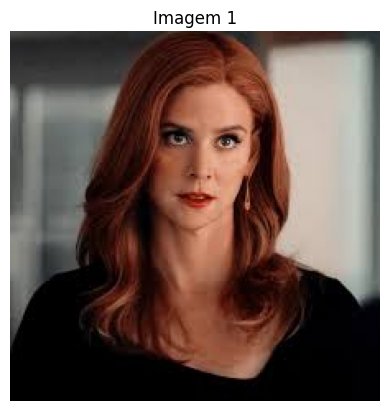

Digite o nome da pessoa: Donna_Paulsen

Imagem 2: Donna_Paulsen2 (1).jpg


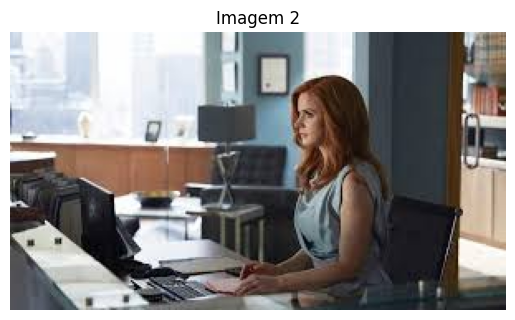

Digite o nome da pessoa: Donna_Paulsen

Imagem 3: Donna_Paulsenjpg (1).jpg


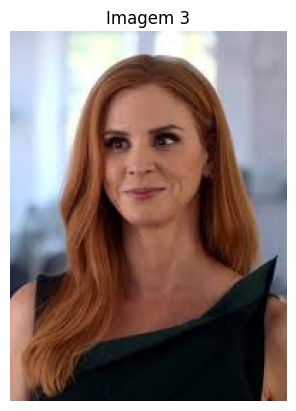

Digite o nome da pessoa: Donna_Paulsen

Imagem 4: Harvey_Specter3 (2).jpg


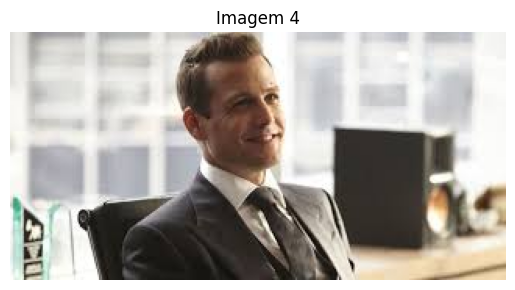

Digite o nome da pessoa: Harvey_Specter

Imagem 5: Harvey_Specter2 (2).jpg


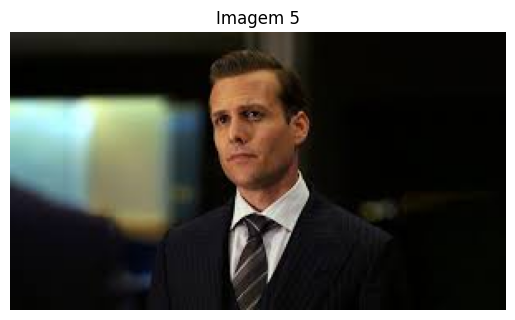

Digite o nome da pessoa: Harvey_Specter

Imagem 6: Hervey-Specter-Suit (2).jpg


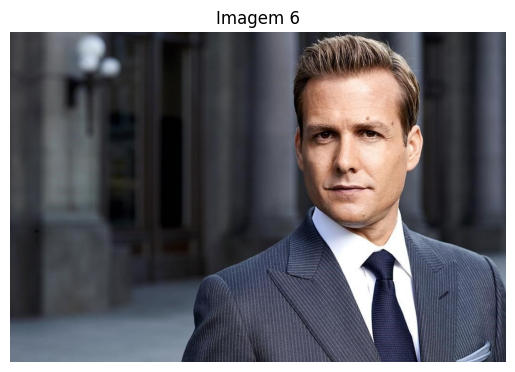

Digite o nome da pessoa: Harvey_Specter

🔄 Treinando com 6 imagens...

🔄 Extraindo embeddings de 6 imagens...
  Processando imagem 1/6: Donna_Paulsen3 (1).jpg
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Modelo de embeddings criado com sucesso!
  Processando imagem 2/6: Donna_Paulsen2 (1).jpg
  Processando imagem 3/6: Donna_Paulsenjpg (1).jpg
  Processando imagem 4/6: Harvey_Specter3 (2).jpg
  Processando imagem 5/6: Harvey_Specter2 (2).jpg
  Processando imagem 6/6: Hervey-Specter-Suit (2).jpg
✅ Classes encontradas: ['Donna_Paulsen' 'Harvey_Specter']
🔄 Treinando classificador...
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7418 - val_accuracy: 0.0000e+00 - val_loss: 1.2278
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5000 - loss: 0.4811 - val_accuracy: 0.0000e+00 - val_loss: 1.6576
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 0.2419 - val_accuracy: 0.0000e+00 - val_loss: 2.0571
Epoch 4/30
1/1 ━━━━

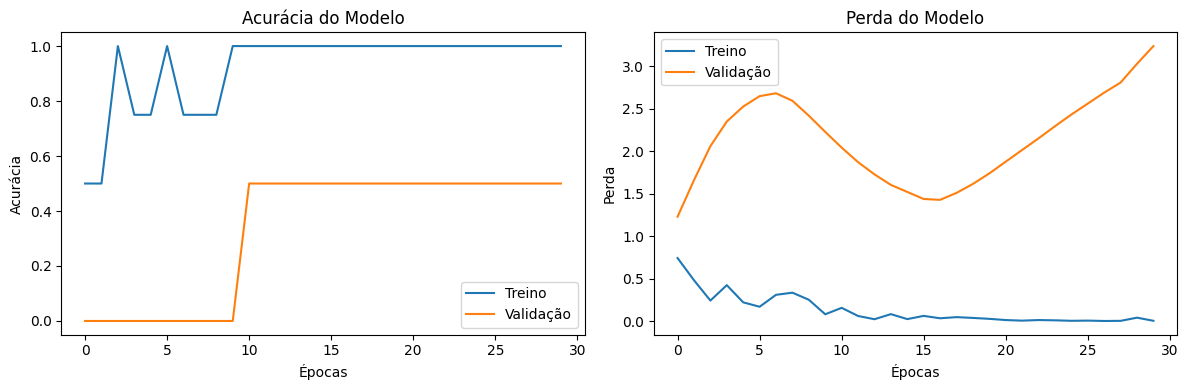

✅ Modelo treinado com sucesso!

🎯 SISTEMA DE RECONHECIMENTO FACIAL
1️⃣  Treinar com imagens próprias (upload)
2️⃣  Usar dataset de exemplo (teste rápido)
3️⃣  Carregar modelo salvo
4️⃣  Reconhecer faces em uma imagem
5️⃣  Salvar modelo atual
6️⃣  Sair
👉 Escolha uma opção (1-6): 6

👋 Até logo!


In [22]:
# Executar o sistema
if __name__ == "__main__":
    main()